# Сравнение зарплат учителей в Москве и Нижнем Новгороде

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
dataNn=pd.read_csv('../data/processed/nnTeacher.csv')
dataMo=pd.read_csv('../data/processed/moTeacher.csv')
display(dataMo.head())
display(dataNn.head())

,city,name,salary_from,salary_to,employer
0,Москва,Учитель английского языка,100000.0,NaN,ГБОУ Школа № 1374
1,Москва,Учитель английского языка,120000.0,NaN,ГБОУ Школа № 950
2,Москва,Преподаватель английского языка,70000.0,NaN,ФГАОУ ВО МГТУ им. Н.Э. Баумана
3,Москва,Учитель физической культуры,84500.0,95500.0,ГБОУ Города Москвы Школа № 1366
4,Москва,Учитель физической культуры,95000.0,NaN,ГБОУ Школа № 814


,city,name,salary_from,salary_to,employer
0,Нижний Новгород,Педагог дополнительного образования для дошкол...,70000,90000.0,Детский центр АЗБУКА ДЕТСТВА
1,Нижний Новгород,Педагог-организатор (библиотека),50000,50000.0,АНОО Школа 800
2,Нижний Новгород,Педагог дополнительного образования (раннее ра...,30000,NaN,Кудряшова Дарья Константиновна
3,Нижний Новгород,Преподаватель Английского языка в Международну...,70000,NaN,Международная онлайн школа Shkola
4,Нижний Новгород,Учитель ИЗО и технологии в онлайн-школу,50000,NaN,Международная онлайн школа Shkola


Так как у нас есть варианты, где зарплаты имеют вилку, мы возьмем среднее. На самом деле это не совсем верно, так как часто по факту что-бы получить верхнюю часть зп нужно показать нереальный результат.

In [3]:
dataMo['salary'] = dataMo[['salary_from', 'salary_to']].mean(axis=1, skipna=True)
dataNn['salary'] = dataNn[['salary_from', 'salary_to']].mean(axis=1, skipna=True)
dataMo=dataMo['salary'].dropna().astype('int32')
dataNn=dataNn['salary'].dropna().astype('int32')

In [4]:
print(dataMo[dataMo.values == 300000])


35    300000
Name: salary, dtype: int32


## Как выглядят эти зарплаты на прямой?

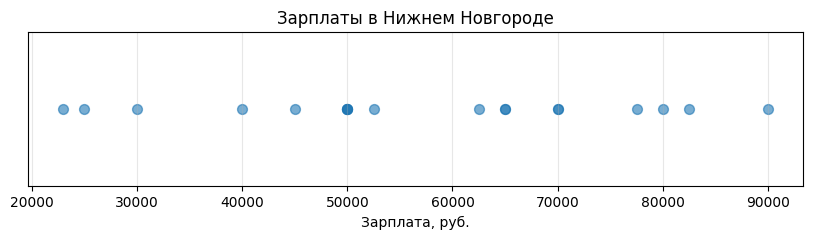

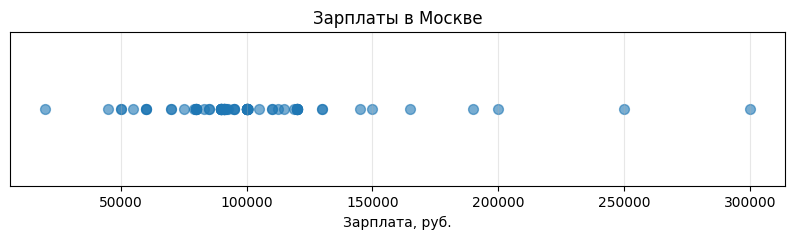

In [5]:
def plot_salaries(salaries, city_name):
    """
    Простой scatter plot зарплат на одной оси.
    
    Args:
        salaries: Series или список зарплат
        city_name: название города для заголовка
    """
    
    # Создаем график
    plt.figure(figsize=(10, 2))
    plt.scatter(salaries, [1] * len(salaries), 
               alpha=0.6, s=50)
    plt.title(f'Зарплаты в {city_name}')
    plt.yticks([])  # Убираем ось Y
    plt.xlabel('Зарплата, руб.')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_salaries(dataNn, 'Нижнем Новгороде')
plot_salaries(dataMo, 'Москве')

## Среднее, медиана, мода

In [6]:
stats_data = {
    'Москва': [
        dataMo.mean(),
        dataMo.median(),
        dataMo.mode().iloc[0] if not dataMo.mode().empty else None
        ],
    'Нижний Новгород': [
        dataNn.mean(),
        dataNn.median(),
        dataNn.mode().iloc[0] if not dataNn.mode().empty else None
    ]
}
stats= pd.DataFrame(stats_data, index=['Среднее', 'Медиана', 'Мода'])
stats

,Москва,Нижний Новгород
Среднее,101313.253012,56736.842105
Медиана,92500.000000,52500.000000
Мода,100000.000000,50000.000000


## Выбросы

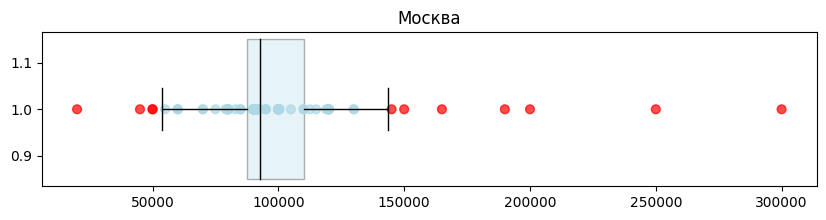

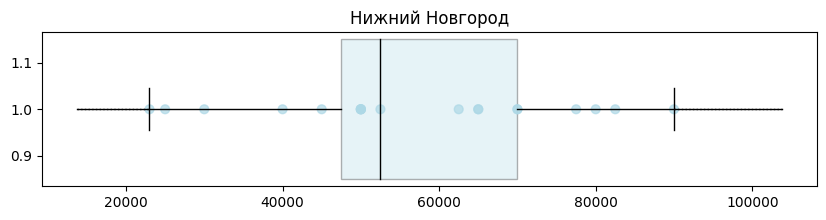

In [7]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch
def custom_boxplot(data, show_points=True, box_width=0.15, title='График', label_all_points=False, coef=1.5):
    """
    Улучшенный boxplot с подписью всех значений и ручным расчетом усов.
    Усы всегда отображаются на расстоянии 1.5 * IQR, даже если нет данных в этих точках.
    """
    fig, ax = plt.subplots(figsize=(10, 2))
    
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    iqr = q3 - q1
    
    lower_bound = q1 - coef * iqr
    upper_bound = q3 + coef * iqr
    
    data_min = np.min(data)
    data_max = np.max(data)
    
    lower_whisker = max(lower_bound, data_min)
    upper_whisker = min(upper_bound, data_max)
    
    y_pos = 1
    box_height = box_width * 2
    
    whisker_props = dict(color='black', linewidth=1)
    ax.plot([lower_bound, q1], [y_pos, y_pos], **whisker_props)  # Левый ус (полная длина)
    ax.plot([q3, upper_bound], [y_pos, y_pos], **whisker_props)  # Правый ус (полная длина)
    
    cap_width = box_width * 0.3
    ax.plot([lower_whisker, lower_whisker], [y_pos - cap_width, y_pos + cap_width], **whisker_props)
    ax.plot([upper_whisker, upper_whisker], [y_pos - cap_width, y_pos + cap_width], **whisker_props)
    
    if lower_bound < data_min:
        ax.plot([lower_bound, lower_whisker], [y_pos, y_pos], 
                linestyle=':', color='black', linewidth=1)
    if upper_bound > data_max:
        ax.plot([upper_whisker, upper_bound], [y_pos, y_pos], 
                linestyle=':', color='black', linewidth=1)
    
    box_path = Path([
        [q1, y_pos - box_height/2],
        [q1, y_pos + box_height/2],
        [q3, y_pos + box_height/2],
        [q3, y_pos - box_height/2],
        [q1, y_pos - box_height/2]
    ], [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY])
    
    box_patch = PathPatch(
        box_path,
        facecolor='lightblue',
        alpha=0.3,
        edgecolor='black',
        linewidth=1
    )
    ax.add_patch(box_patch)
    
    ax.plot([median, median], [y_pos - box_height/2, y_pos + box_height/2], color='black', linewidth=1)
    
    outliers = [x for x in data if x < lower_bound or x > upper_bound]
    
    if show_points:
        colors = ['red' if x in outliers else 'lightblue' for x in data]
        
        scatter = ax.scatter(
            data, 
            np.full_like(data, y_pos),
            c=colors,
            alpha=0.7,
            s=40,
            picker=True
        )

        if label_all_points:
            for i, value in enumerate(data):
                ax.text(
                    value, 
                    y_pos + 0.05,  
                    f'{value:.0f}',
                    ha='center', 
                    va='bottom',
                    fontsize=8,
                    color='black'
                )
    plt.title(title)
custom_boxplot(dataMo, title='Москва')
custom_boxplot(dataNn, title='Нижний Новгород')

## Все те же показатели без выбросов

In [8]:
def remove_outliers_tukey(sir):
    """
    Удаляет выбросы по правилу Тьюки для указанного столбца
    """
    Q1 = sir.quantile(0.25)
    Q3 = sir.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return sir[(sir >= lower_bound) & (sir <= upper_bound)]

df_clean_Mo = remove_outliers_tukey(dataMo)
df_clean_Nn = remove_outliers_tukey(dataNn)

stats_data_cl = {
    'Москва': [
        df_clean_Mo.mean(),
        df_clean_Mo.median(),
        df_clean_Mo.mode().iloc[0] if not df_clean_Mo.mode().empty else None
        ]
}
print('После удаления выбросов:')
display(pd.DataFrame(stats_data_cl, index=['Среднее', 'Медиана', 'Мода']))

После удаления выбросов:


,Москва
Среднее,95055.555556
Медиана,92000.000000
Мода,100000.000000


In [13]:
res = pd.DataFrame(index=['Среднее', 'Медиана', 'Мода'])
res["С выбросами"] = stats['Москва']
res["Без выбросов"] = stats_data_cl['Москва']
res["Без выбросов с налогом"] = (res["Без выбросов"]/100)*(100-13)
res["Разница"] = res["С выбросами"] - res["Без выбросов"]
res["%"] = res["Разница"]/(res["Без выбросов"] / 100)

res[["С выбросами", "Без выбросов", "Разница"]] = res[["С выбросами", "Без выбросов", "Разница"]].astype(int)

print('Москва, сравнение')
display(res)

Москва, сравнение


,С выбросами,Без выбросов,Без выбросов с налогом,Разница,%
Среднее,101313,95055,82698.333333,6257,6.583200
Медиана,92500,92000,80040.000000,500,0.543478
Мода,100000,100000,87000.000000,0,0.000000


## Налоги

In [10]:
combined_df = pd.DataFrame({
    'Москва': res["Без выбросов"] * 0.87,
    'Нижний Новгород': stats['Нижний Новгород'] * 0.87
})
combined_df

,Москва,Нижний Новгород
Среднее,82697.85,49361.052632
Медиана,80040.00,45675.000000
Мода,87000.00,43500.000000


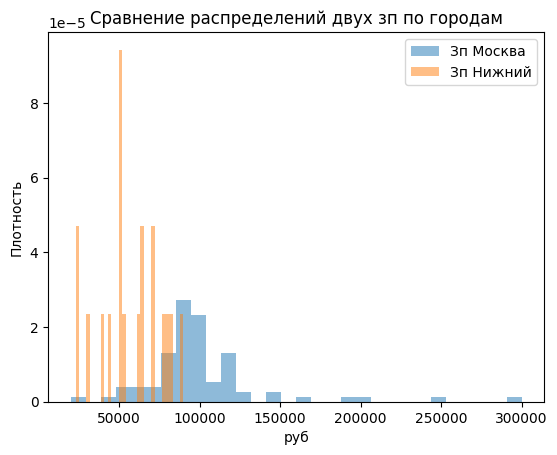

In [11]:
import seaborn as sns
plt.hist(dataMo, alpha=0.5, label='Зп Москва', bins=30, density=True)
plt.hist(dataNn, alpha=0.5, label='Зп Нижний', bins=30, density=True)
plt.legend()
plt.title('Сравнение распределений двух зп по городам')
plt.xlabel('руб')
plt.ylabel('Плотность')
plt.show()

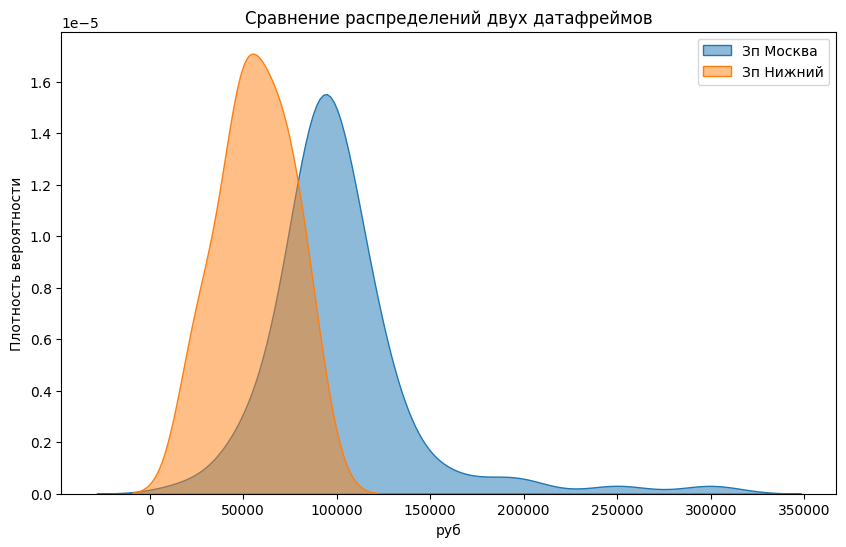

In [12]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=dataMo, label='Зп Москва', fill=True, alpha=0.5)

sns.kdeplot(data=dataNn, label='Зп Нижний', fill=True, alpha=0.5)

plt.title('Сравнение распределений двух датафреймов')
plt.xlabel('руб')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.show()